# Proyecto Integrador de Minería de Datos I  
## Notebook 03 — Análisis exploratorio de datos

**Carrera:** Tecnicatura Superior en Ciencia de Datos e Inteligencia Artificial  
**Asignatura:** Minería de Datos I  
**Dataset utilizado:** `streaming_users_clean.csv`  
**Integrantes:** Thir Ferreyra Nadia Lorena y Constantinidi Leandro Exequiel  
**Comisión:** Turno Tarde  
**Fecha de análisis:** 27 de junio de 2026  

---

## Propósito de esta etapa

En este notebook se analiza el dataset procesado para responder las preguntas formuladas al comienzo del proyecto.

La etapa incluye:

- análisis univariado;
- análisis bivariado;
- análisis multivariado;
- interpretación vinculada con las preguntas del proyecto.

> Interpretar no significa describir únicamente ejes, colores o barras.  
> Interpretar significa explicar qué evidencia aporta el resultado y qué conclusión puede sostenerse.

No se desarrollan modelos predictivos y no se afirma causalidad. Las relaciones observadas representan asociaciones dentro del dataset.


## 1. Preguntas que guían el análisis

1. ¿Cómo se distribuyen los usuarios entre los distintos planes de suscripción?
2. ¿Cómo se distribuye el tiempo mensual de visualización?
3. ¿El tiempo mensual de visualización cambia según el plan contratado?
4. ¿Existe una relación entre la edad y el tiempo mensual de visualización?
5. ¿El patrón de consumo por plan se mantiene al considerar simultáneamente el país?

Estas preguntas determinan qué estadísticas y visualizaciones se utilizan. No se agregan gráficos sin una finalidad analítica.


## 2. Importación de librerías

Se utilizan:

- `pandas` para organizar y resumir los datos;
- `numpy` para cálculos numéricos y línea de tendencia;
- `matplotlib` para construir las visualizaciones.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Carga del dataset procesado

El análisis se realiza exclusivamente sobre el archivo generado en el Notebook 02.

Se crea una copia de control para comprobar al final que el análisis exploratorio no modificó los datos.


In [2]:
rutas_posibles = [
    Path("../data/processed/streaming_users_clean.csv"),
    Path("data/processed/streaming_users_clean.csv"),
    Path("/content/PI_Mineria_Datos_1/data/processed/streaming_users_clean.csv"),
]

ruta_datos = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_datos is None:
    raise FileNotFoundError(
        "No se encontró streaming_users_clean.csv en data/processed/."
    )

df = pd.read_csv(
    ruta_datos,
    parse_dates=["last_login_date"],
)

df_control = df.copy(deep=True)

print(f"Archivo cargado desde: {ruta_datos.resolve()}")
print(f"Dimensiones: {df.shape}")
display(df.head())

Archivo cargado desde: /mnt/data/PI_Mineria_Datos_1_GRUPAL/data/processed/streaming_users_clean.csv
Dimensiones: (8000, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.80,Brasil,Crimen,2025-03-04,1
1,10001,37,Estándar,"1,173.40",Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.00,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.40,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.80,Perú,Thriller,2020-09-30,1


## 4. Validación previa al EDA

Antes de analizar se comprueba que:

- existan 8.000 usuarios;
- no haya identificadores duplicados;
- las variables principales estén completas;
- los únicos faltantes remanentes correspondan a la fecha.

La fecha no será utilizada en las cinco visualizaciones principales, por lo que sus faltantes documentados no impiden responder las preguntas elegidas.


In [3]:
validacion_eda = pd.DataFrame({
    "control": [
        "Cantidad de filas",
        "Cantidad de columnas",
        "user_id duplicados",
        "Nulos en edad",
        "Nulos en plan",
        "Nulos en minutos",
        "Nulos en país",
        "Nulos en género",
        "Nulos en tickets",
        "Nulos en fecha",
    ],
    "resultado": [
        len(df),
        df.shape[1],
        int(df["user_id"].duplicated().sum()),
        int(df["age"].isna().sum()),
        int(df["subscription_plan"].isna().sum()),
        int(df["monthly_watch_time_mins"].isna().sum()),
        int(df["country"].isna().sum()),
        int(df["favorite_genre"].isna().sum()),
        int(df["customer_support_tickets"].isna().sum()),
        int(df["last_login_date"].isna().sum()),
    ],
})

display(validacion_eda)

,control,resultado
0,Cantidad de filas,8000
1,Cantidad de columnas,8
2,user_id duplicados,0
3,Nulos en edad,0
4,Nulos en plan,0
5,Nulos en minutos,0
6,Nulos en país,0
7,Nulos en género,0
8,Nulos en tickets,0
9,Nulos en fecha,501


## 5. Resumen descriptivo general

`user_id` no se incluye en el resumen numérico porque es un identificador, no una medida.

Se calculan media, mediana, desviación estándar, cuartiles, mínimo y máximo para las variables cuantitativas.


In [4]:
variables_numericas = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets",
]

resumen_numerico = df[variables_numericas].describe().T
resumen_numerico["mediana"] = df[variables_numericas].median()
resumen_numerico["asimetria"] = df[variables_numericas].skew()

display(
    resumen_numerico[
        [
            "count",
            "mean",
            "mediana",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "asimetria",
        ]
    ]
)

,count,mean,mediana,std,min,25%,50%,75%,max,asimetria
age,"8,000.00",33.70,33.00,11.46,13.00,26.00,33.00,41.00,80.00,0.24
monthly_watch_time_mins,"8,000.00",800.88,770.85,490.27,0.00,499.15,770.85,"1,058.65","4,193.70",2.43
customer_support_tickets,"8,000.00",0.80,1.00,0.89,0.00,0.00,1.00,1.00,5.00,1.14


### Lectura general

- La edad se concentra alrededor de los 33 años.
- El tiempo mensual presenta mayor variabilidad y una asimetría positiva: una minoría de usuarios registra consumos muy altos.
- Los tickets se concentran en valores bajos.

El promedio por sí solo no describe completamente el tiempo de visualización. Por eso se complementará con mediana, desviación, histograma y boxplot.


# 6. Análisis univariado

## Visualización 1 — Distribución de usuarios por plan

### Pregunta

¿Cómo se distribuyen los usuarios entre los distintos planes de suscripción?

### Técnica elegida

Se utiliza un gráfico de barras porque `subscription_plan` es una variable categórica. La altura de cada barra representa la frecuencia de usuarios.


In [5]:
orden_planes = ["Básico", "Estándar", "Premium"]

tabla_planes = (
    df["subscription_plan"]
    .value_counts()
    .reindex(orden_planes)
    .rename("cantidad")
    .to_frame()
)

tabla_planes["porcentaje"] = (
    tabla_planes["cantidad"] / len(df) * 100
).round(2)

display(tabla_planes)

,cantidad,porcentaje
subscription_plan,,
Básico,3600,45.00
Estándar,2817,35.21
Premium,1583,19.79


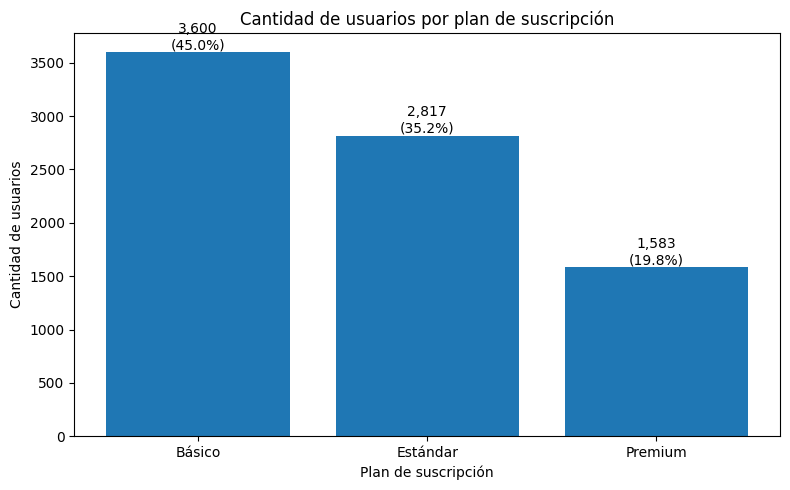

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    tabla_planes.index,
    tabla_planes["cantidad"],
)

ax.set_title("Cantidad de usuarios por plan de suscripción")
ax.set_xlabel("Plan de suscripción")
ax.set_ylabel("Cantidad de usuarios")

for barra, cantidad, porcentaje in zip(
    barras,
    tabla_planes["cantidad"],
    tabla_planes["porcentaje"],
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad:,}\n({porcentaje:.1f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Interpretación

El plan Básico concentra 3.600 usuarios, equivalentes al 45 % del total. El plan Estándar representa aproximadamente el 35,2 % y Premium el 19,8 %.

La composición de la base no está equilibrada entre planes: Premium es el grupo menos numeroso. Esto debe tenerse presente al comparar cantidades absolutas. Para analizar consumo por plan conviene utilizar medidas como promedio y mediana, que no dependen directamente del tamaño del grupo.

### Conclusión de la pregunta

La cartera de usuarios se concentra principalmente en los planes Básico y Estándar. Aproximadamente uno de cada cinco usuarios pertenece al plan Premium.


## Visualización 2 — Distribución del tiempo mensual de visualización

### Pregunta

¿Cómo se distribuye el tiempo mensual de visualización?

### Técnica elegida

Se utiliza un histograma porque la variable es cuantitativa continua. El gráfico permite observar concentración, dispersión y asimetría.


In [7]:
estadisticas_tiempo = pd.Series({
    "Media": df["monthly_watch_time_mins"].mean(),
    "Mediana": df["monthly_watch_time_mins"].median(),
    "Desviación estándar": df["monthly_watch_time_mins"].std(),
    "Coeficiente de variación (%)": (
        df["monthly_watch_time_mins"].std()
        / df["monthly_watch_time_mins"].mean()
        * 100
    ),
    "Asimetría": df["monthly_watch_time_mins"].skew(),
    "Mínimo": df["monthly_watch_time_mins"].min(),
    "Máximo": df["monthly_watch_time_mins"].max(),
}).round(2)

display(estadisticas_tiempo.to_frame("valor"))

,valor
Media,800.88
Mediana,770.85
Desviación estándar,490.27
Coeficiente de variación (%),61.22
Asimetría,2.43
Mínimo,0.00
Máximo,"4,193.70"


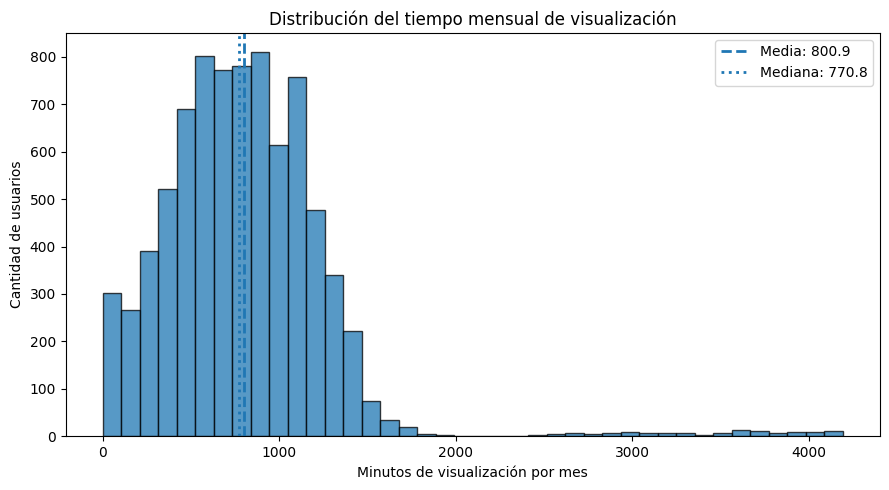

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["monthly_watch_time_mins"],
    bins=40,
    edgecolor="black",
    alpha=0.75,
)

media_tiempo = df["monthly_watch_time_mins"].mean()
mediana_tiempo = df["monthly_watch_time_mins"].median()

ax.axvline(
    media_tiempo,
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_tiempo:.1f}",
)

ax.axvline(
    mediana_tiempo,
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {mediana_tiempo:.1f}",
)

ax.set_title("Distribución del tiempo mensual de visualización")
ax.set_xlabel("Minutos de visualización por mes")
ax.set_ylabel("Cantidad de usuarios")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación

La media es de aproximadamente 800,9 minutos y la mediana de 770,9 minutos. La media se ubica por encima de la mediana y la asimetría es positiva, lo que indica una cola hacia valores altos.

El coeficiente de variación supera el 60 %, por lo que el comportamiento de consumo es heterogéneo. Algunos usuarios registran consumos muy superiores al centro de la distribución.

Esos valores altos no se eliminan: en el Notebook 02 se comprobó que son físicamente posibles y pueden representar usuarios intensivos reales.

### Conclusión de la pregunta

El usuario típico se encuentra cerca de 771 minutos mensuales, pero existe una minoría de consumo elevado que aumenta el promedio. Por eso la mediana describe mejor el centro habitual que la media por sí sola.


# 7. Análisis bivariado

## Visualización 3 — Tiempo mensual según plan

### Pregunta

¿El tiempo mensual de visualización cambia según el plan contratado?

### Técnica elegida

Se utiliza un boxplot porque permite comparar simultáneamente:

- mediana;
- cuartiles;
- dispersión;
- valores extremos;

entre las tres categorías del plan.


In [9]:
resumen_plan_tiempo = (
    df.groupby("subscription_plan")["monthly_watch_time_mins"]
    .agg(
        usuarios="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max",
    )
    .reindex(orden_planes)
    .round(2)
)

display(resumen_plan_tiempo)

diferencias_relativas = pd.Series({
    "Estándar respecto de Básico (%)": (
        resumen_plan_tiempo.loc["Estándar", "media"]
        / resumen_plan_tiempo.loc["Básico", "media"]
        - 1
    ) * 100,
    "Premium respecto de Básico (%)": (
        resumen_plan_tiempo.loc["Premium", "media"]
        / resumen_plan_tiempo.loc["Básico", "media"]
        - 1
    ) * 100,
    "Premium respecto de Estándar (%)": (
        resumen_plan_tiempo.loc["Premium", "media"]
        / resumen_plan_tiempo.loc["Estándar", "media"]
        - 1
    ) * 100,
}).round(2)

display(diferencias_relativas.to_frame("diferencia_relativa"))

,usuarios,media,mediana,desviacion,minimo,maximo
subscription_plan,,,,,,
Básico,3600,597.00,552.70,458.97,0.00,"4,142.60"
Estándar,2817,871.70,840.00,436.59,0.00,"4,193.70"
Premium,1583,"1,138.53","1,127.00",423.34,66.10,"4,188.70"


,diferencia_relativa
Estándar respecto de Básico (%),46.01
Premium respecto de Básico (%),90.71
Premium respecto de Estándar (%),30.61


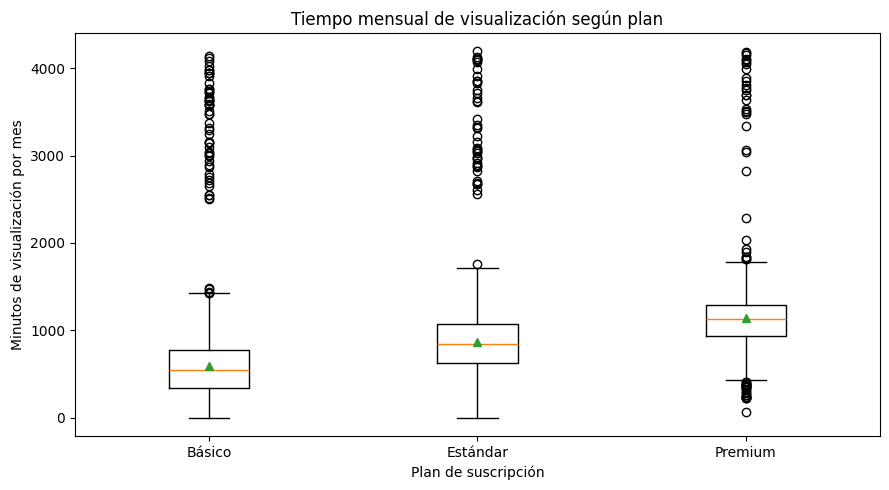

In [10]:
datos_boxplot = [
    df.loc[
        df["subscription_plan"] == plan,
        "monthly_watch_time_mins",
    ]
    for plan in orden_planes
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    datos_boxplot,
    tick_labels=orden_planes,
    showmeans=True,
)

ax.set_title("Tiempo mensual de visualización según plan")
ax.set_xlabel("Plan de suscripción")
ax.set_ylabel("Minutos de visualización por mes")

plt.tight_layout()
plt.show()

### Interpretación

Las medianas aumentan de manera ordenada:

- Básico: 552,7 minutos;
- Estándar: 840 minutos;
- Premium: 1.127 minutos.

El promedio de Estándar es aproximadamente 46 % mayor que el de Básico. Premium supera a Básico en cerca de 91 % y a Estándar en alrededor de 31 %.

También existe superposición entre las distribuciones. Esto significa que el plan no determina por sí solo el comportamiento de cada usuario: algunos usuarios Básicos consumen más que algunos Premium. Sin embargo, a nivel grupal la diferencia es clara y consistente.

### Conclusión de la pregunta

El plan de suscripción presenta una asociación relevante con el tiempo de visualización. Los planes superiores concentran, en promedio y mediana, un mayor nivel de consumo.

No puede afirmarse que contratar un plan superior cause el aumento. El dataset muestra asociación, no causalidad.


## Visualización 4 — Edad y tiempo mensual de visualización

### Pregunta

¿Existe una relación entre la edad y el tiempo mensual de visualización?

### Técnica elegida

Se utiliza un gráfico de dispersión porque ambas variables son numéricas.

Se agrega:

- una línea de tendencia lineal;
- el coeficiente de correlación de Pearson;
- el coeficiente de determinación aproximado.

La correlación evalúa asociación lineal. Un valor cercano a cero no descarta relaciones no lineales, pero sí indica que no existe un patrón lineal importante.


In [11]:
correlacion_edad_tiempo = df[
    ["age", "monthly_watch_time_mins"]
].corr().iloc[0, 1]

pendiente, intercepto = np.polyfit(
    df["age"],
    df["monthly_watch_time_mins"],
    1,
)

r_cuadrado = correlacion_edad_tiempo ** 2

resultado_correlacion = pd.Series({
    "Correlación de Pearson": correlacion_edad_tiempo,
    "Pendiente estimada": pendiente,
    "R² aproximado": r_cuadrado,
}).round(6)

display(resultado_correlacion.to_frame("valor"))

,valor
Correlación de Pearson,0.01
Pendiente estimada,0.28
R² aproximado,0.00


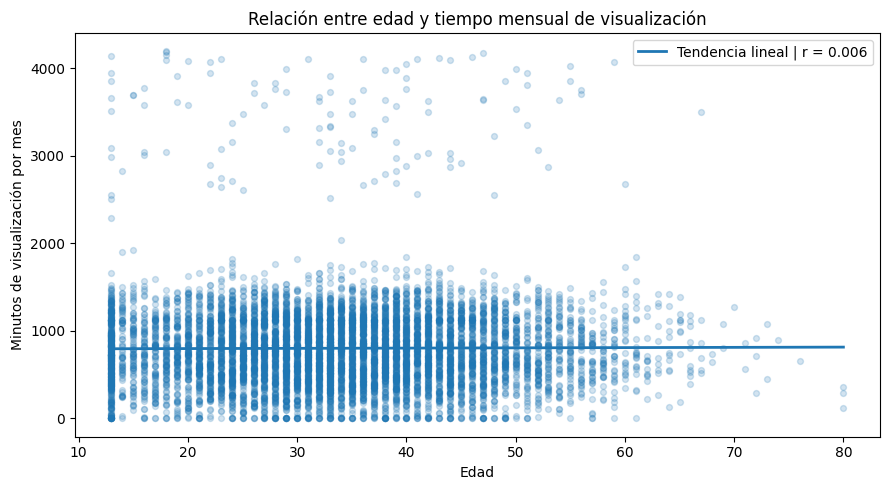

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    df["age"],
    df["monthly_watch_time_mins"],
    alpha=0.20,
    s=18,
)

x_linea = np.linspace(
    df["age"].min(),
    df["age"].max(),
    200,
)

y_linea = pendiente * x_linea + intercepto

ax.plot(
    x_linea,
    y_linea,
    linewidth=2,
    label=(
        f"Tendencia lineal | r = "
        f"{correlacion_edad_tiempo:.3f}"
    ),
)

ax.set_title("Relación entre edad y tiempo mensual de visualización")
ax.set_xlabel("Edad")
ax.set_ylabel("Minutos de visualización por mes")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación

La correlación de Pearson es aproximadamente 0,0065, un valor prácticamente nulo. La nube de puntos no muestra una dirección ascendente o descendente clara y la línea de tendencia es casi horizontal.

El valor de R² es cercano a cero. Esto indica que una relación lineal basada solamente en la edad explicaría una proporción despreciable de la variación del tiempo mensual.

La pendiente estimada no debe interpretarse como un efecto real. Aunque matemáticamente es levemente positiva, su magnitud es mínima frente a la dispersión observada.

### Conclusión de la pregunta

Dentro de este dataset, la edad no presenta una asociación lineal relevante con el tiempo mensual de visualización. La edad, utilizada de manera aislada, no permite caracterizar el nivel de consumo.


# 8. Análisis multivariado

## Visualización 5 — Consumo medio por país y plan

### Pregunta

¿El patrón de consumo por plan se mantiene cuando se considera simultáneamente el país?

### Variables utilizadas

- `country`: primera variable categórica;
- `subscription_plan`: segunda variable categórica;
- `monthly_watch_time_mins`: variable numérica resumida mediante la media.

### Técnica elegida

Se construye una tabla dinámica y un mapa de calor. Cada celda representa el consumo medio de una combinación país–plan.

Esta visualización permite analizar tres variables simultáneamente sin perder claridad.


In [13]:
matriz_pais_plan = (
    df.pivot_table(
        index="country",
        columns="subscription_plan",
        values="monthly_watch_time_mins",
        aggfunc="mean",
    )
    .reindex(columns=orden_planes)
    .round(1)
)

display(matriz_pais_plan)

subscription_plan,Básico,Estándar,Premium
country,,,
Argentina,606.30,879.60,"1,154.60"
Brasil,615.70,867.00,"1,168.80"
Chile,570.50,853.50,"1,174.50"
Colombia,598.90,872.30,"1,088.70"
México,593.30,874.20,"1,108.90"
Perú,605.50,892.10,"1,138.00"
Uruguay,590.20,864.20,"1,137.20"


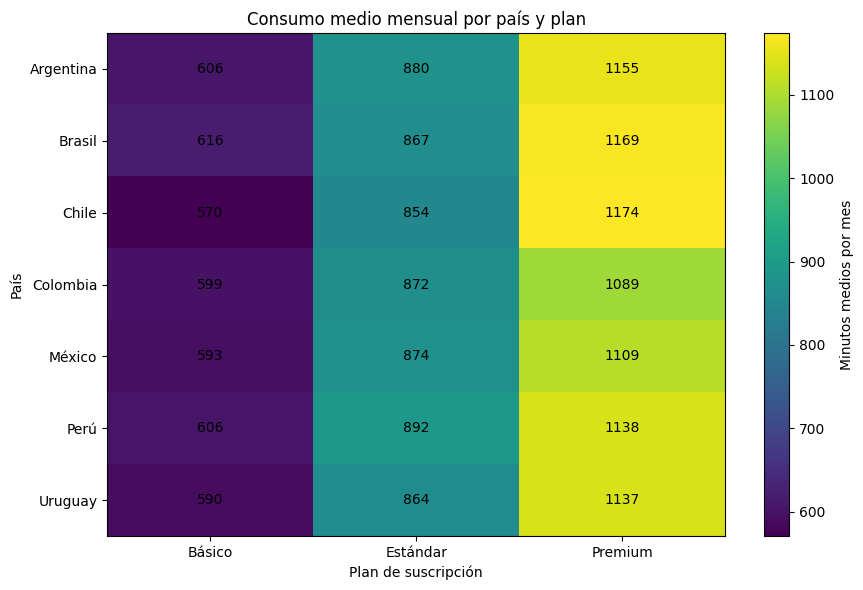

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

imagen = ax.imshow(
    matriz_pais_plan.values,
    aspect="auto",
)

ax.set_xticks(range(len(matriz_pais_plan.columns)))
ax.set_xticklabels(matriz_pais_plan.columns)

ax.set_yticks(range(len(matriz_pais_plan.index)))
ax.set_yticklabels(matriz_pais_plan.index)

ax.set_title("Consumo medio mensual por país y plan")
ax.set_xlabel("Plan de suscripción")
ax.set_ylabel("País")

for fila in range(matriz_pais_plan.shape[0]):
    for columna in range(matriz_pais_plan.shape[1]):
        ax.text(
            columna,
            fila,
            f"{matriz_pais_plan.iloc[fila, columna]:.0f}",
            ha="center",
            va="center",
        )

fig.colorbar(
    imagen,
    ax=ax,
    label="Minutos medios por mes",
)

plt.tight_layout()
plt.show()

### Interpretación

En los siete países se repite el mismo orden:

> Premium > Estándar > Básico

Las diferencias entre países dentro de un mismo plan son moderadas frente a las diferencias entre planes. Por ejemplo, los promedios Premium se mantienen aproximadamente entre 1.089 y 1.175 minutos, mientras que los Básicos se ubican cerca de 571 a 616 minutos.

Esto indica que la asociación entre plan y consumo no se explica por un único país. El patrón aparece de forma consistente en Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay.

### Conclusión de la pregunta

Al controlar visualmente por país, el plan continúa siendo la variable que organiza con mayor claridad el consumo medio. El país introduce variaciones, pero no modifica el orden general entre los planes.


# 9. Síntesis de respuestas

La siguiente tabla diferencia la evidencia, su interpretación y la conclusión correspondiente.


In [15]:
sintesis = pd.DataFrame({
    "pregunta": [
        "¿Cómo se distribuyen los usuarios por plan?",
        "¿Cómo se distribuye el tiempo mensual?",
        "¿El consumo cambia según el plan?",
        "¿La edad se relaciona con el consumo?",
        "¿El patrón por plan se mantiene entre países?",
    ],
    "evidencia": [
        "Básico 45 %, Estándar 35,2 %, Premium 19,8 %",
        "Media 800,9; mediana 770,9; asimetría positiva",
        "Medianas: 552,7; 840; 1.127 minutos",
        "Correlación de Pearson aproximada: 0,0065",
        "En los siete países: Premium > Estándar > Básico",
    ],
    "interpretacion": [
        "La base se concentra en los planes Básico y Estándar",
        "Existe heterogeneidad y una cola de consumos altos",
        "Los planes superiores presentan mayor consumo grupal",
        "No se observa una asociación lineal relevante",
        "El plan conserva su patrón al considerar el país",
    ],
    "conclusion": [
        "Premium es el grupo menos numeroso",
        "La mediana representa mejor el centro habitual",
        "El plan está asociado con el nivel de consumo",
        "La edad aislada no caracteriza el consumo",
        "El país no revierte el orden general entre planes",
    ],
})

display(sintesis)

,pregunta,evidencia,interpretacion,conclusion
0,¿Cómo se distribuyen los usuarios por plan?,"Básico 45 %, Estándar 35,2 %, Premium 19,8 %",La base se concentra en los planes Básico y Es...,Premium es el grupo menos numeroso
1,¿Cómo se distribuye el tiempo mensual?,"Media 800,9; mediana 770,9; asimetría positiva",Existe heterogeneidad y una cola de consumos a...,La mediana representa mejor el centro habitual
2,¿El consumo cambia según el plan?,"Medianas: 552,7; 840; 1.127 minutos",Los planes superiores presentan mayor consumo ...,El plan está asociado con el nivel de consumo
3,¿La edad se relaciona con el consumo?,"Correlación de Pearson aproximada: 0,0065",No se observa una asociación lineal relevante,La edad aislada no caracteriza el consumo
4,¿El patrón por plan se mantiene entre países?,En los siete países: Premium > Estándar > Básico,El plan conserva su patrón al considerar el país,El país no revierte el orden general entre planes


# 10. Hallazgos principales

1. **Composición de usuarios:** el 80,2 % pertenece a los planes Básico o Estándar.
2. **Consumo heterogéneo:** el tiempo mensual presenta dispersión elevada y una cola de usuarios intensivos.
3. **Plan y consumo:** existe una diferencia clara y ordenada entre las medianas y medias de los planes.
4. **Edad y consumo:** la relación lineal es prácticamente inexistente.
5. **Consistencia geográfica:** el patrón Premium–Estándar–Básico se repite en todos los países.

## Hallazgo central

> El plan de suscripción es la variable que presenta la asociación más clara con el tiempo mensual de visualización. La edad no muestra una relación lineal relevante y el país introduce variaciones menores sin alterar el patrón general entre planes.


# 11. Limitaciones del análisis exploratorio

- El dataset no incluye información sobre precio, antigüedad de la cuenta, cantidad de perfiles, dispositivos o tipo de contenido efectivamente reproducido.
- No se conoce el proceso real de generación de los datos ni si la muestra representa a toda una plataforma.
- Parte del tiempo mensual fue imputado por mediana de plan. Las conclusiones dependen de esa decisión documentada.
- Existen 501 fechas de último ingreso no interpretables con suficiente seguridad.
- Las asociaciones observadas no demuestran causalidad.
- El plan podría estar relacionado con variables no disponibles que también influyan sobre el consumo.

Estas limitaciones restringen el alcance de las conclusiones, pero no invalidan los patrones descriptivos observados.


# 12. Decisión para la etapa siguiente

El Notebook 04 aplicará PCA sobre variables numéricas que representen dimensiones diferentes del usuario.

Se considerarán:

- edad;
- tiempo mensual de visualización;
- tickets de soporte;
- días desde el último ingreso, calculados solo cuando exista una fecha válida.

Antes de PCA será necesario:

1. justificar el tratamiento de las fechas faltantes para esa etapa;
2. estandarizar las variables porque sus unidades y escalas son diferentes;
3. evaluar la varianza explicada antes de decidir cuántos componentes conservar.


# 13. Verificación de integridad

El análisis exploratorio debe resumir y visualizar el dataset, no modificarlo.

Se compara el DataFrame final con la copia creada al cargar el archivo.


In [16]:
dataset_sin_modificaciones = df.equals(df_control)

print(
    "¿El dataset procesado se mantuvo sin modificaciones? "
    f"{dataset_sin_modificaciones}"
)

if not dataset_sin_modificaciones:
    raise AssertionError(
        "El DataFrame fue modificado durante el EDA."
    )

¿El dataset procesado se mantuvo sin modificaciones? True


## Resultado final

La comprobación devuelve `True`.

El análisis exploratorio se realizó sobre el dataset procesado sin introducir nuevas transformaciones. Las cinco visualizaciones principales quedan definidas para ser reutilizadas posteriormente en la página `02_EDA.py` de Streamlit.
